# Zambia transmission LineType validation

This notebook compares the transmission-network representation in:

1. **PyPSA-Zambia `main`** (current/legacy LineType approach), and
2. **the new Zambia-specific LineType approach** (`improve-zambia-line-types`).

The objective is not to show that one approach simply gives larger or smaller capacities.
Instead, the validation checks whether the new approach replaces generic or legacy assumptions with
representative conductor configurations and electrical parameters supported by Zambia-specific
transmission evidence.

## Evidence used

- **Topology / voltage / circuits:** the PyPSA-Zambia network inputs derived from OSM.
- **Conductor evidence:** JICA/ZESCO transmission inventories (2005/06).
- **Electrical parameters at 132/220/330 kV:** the published ZESCO PSAT representation in  
  Nyoni et al. (2021), *Energies* 14(17), 5330.
- **330 kV conductor configuration:** JICA/ZESCO inventory and recent ZTIP documentation.

Important limitation: no Zambia-specific R/X/C reference comparable to the PSAT data was
identified for 66 or 88 kV. Those voltage levels are therefore validated primarily against
documented conductor inventories rather than electrical-parameter reference values.

Sources:

- JICA/ZESCO transmission inventory: https://openjicareport.jica.go.jp/pdf/11871027_02.pdf
- Nyoni et al. (2021): https://doi.org/10.3390/en14175330


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


## 1. Network paths

Generate both approaches from the **same PyPSA-Zambia checkout and the same validation-dispatch
configuration**, copying the resulting networks to a separate validation directory after each run.

The notebook expects:

```text
~/zambia-linetype-validation/
├── main/
│   ├── base.nc
│   ├── elec.nc
│   └── elec_s.nc
└── new_custom/
    ├── base.nc
    ├── elec.nc
    └── elec_s.nc
```

The `.nc` files used for this exercise are not committed to `zambia-dev-notebooks`.


In [2]:
RUN = "validation_dispatch_zambia_2023"

VALIDATION_ROOT = Path.home() / "zambia-linetype-validation"

NETWORK_PATHS = {
    "main": {
        "base": VALIDATION_ROOT / "main" / "base.nc",
        "elec": VALIDATION_ROOT / "main" / "elec.nc",
        "elec_s": VALIDATION_ROOT / "main" / "elec_s.nc",
    },
    "new_custom": {
        "base": VALIDATION_ROOT / "new_custom" / "base.nc",
        "elec": VALIDATION_ROOT / "new_custom" / "elec.nc",
        "elec_s": VALIDATION_ROOT / "new_custom" / "elec_s.nc",
    },
}

path_check = pd.DataFrame(
    [
        {"approach": approach, "stage": stage, "path": path, "exists": path.exists()}
        for approach, stages in NETWORK_PATHS.items()
        for stage, path in stages.items()
    ]
)

path_check


,approach,stage,path,exists
0,main,base,/home/daniele-lerede/zambia-linetype-validatio...,True
1,main,elec,/home/daniele-lerede/zambia-linetype-validatio...,True
2,main,elec_s,/home/daniele-lerede/zambia-linetype-validatio...,True
3,new_custom,base,/home/daniele-lerede/zambia-linetype-validatio...,True
4,new_custom,elec,/home/daniele-lerede/zambia-linetype-validatio...,True
5,new_custom,elec_s,/home/daniele-lerede/zambia-linetype-validatio...,True


In [3]:
commit_paths = {
    approach: VALIDATION_ROOT / approach / "commit.txt"
    for approach in NETWORK_PATHS
}

config_paths = {
    approach: VALIDATION_ROOT
    / approach
    / "config.zm.validation_dispatch.yaml"
    for approach in NETWORK_PATHS
}

run_metadata = pd.DataFrame(
    [
        {
            "approach": approach,
            "commit": commit_paths[approach].read_text().strip(),
            "config": str(config_paths[approach]),
        }
        for approach in NETWORK_PATHS
    ]
)

display(run_metadata)

configs_identical = (
    config_paths["main"].read_text()
    == config_paths["new_custom"].read_text()
)

print("Validation configs identical:", configs_identical)

assert configs_identical, (
    "main and new_custom were not generated with identical "
    "validation configurations"
)


,approach,commit,config
0,main,f3b71a8b9b58cb95f049ab3d3ee8f00c9f699635,/home/daniele-lerede/zambia-linetype-validatio...
1,new_custom,374e7d7f2d89956c7ccba99c4f8665951d7ec195,/home/daniele-lerede/zambia-linetype-validatio...


Validation configs identical: True


In [4]:
missing = path_check.loc[~path_check["exists"]]

if not missing.empty:
    print("Missing network files:")
    display(missing)
    print(
        "\nGenerate the missing networks before continuing. "
        "The analysis below requires at least base.nc; elec.nc and elec_s.nc "
        "are used to verify propagation through the workflow."
    )


In [5]:
networks = {
    approach: {
        stage: pypsa.Network(path)
        for stage, path in stages.items()
        if path.exists()
    }
    for approach, stages in NETWORK_PATHS.items()
}

{
    approach: list(stages)
    for approach, stages in networks.items()
}


INFO:pypsa.io:Imported network base.nc has buses, lines, line_types, transformers


INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, line_types, loads, storage_units, transformers


INFO:pypsa.io:Imported network elec_s.nc has buses, carriers, generators, lines, line_types, loads, storage_units


INFO:pypsa.io:Imported network base.nc has buses, lines, line_types, transformers


INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, line_types, loads, storage_units, transformers


INFO:pypsa.io:Imported network elec_s.nc has buses, carriers, generators, lines, line_types, loads, storage_units


{'main': ['base', 'elec', 'elec_s'], 'new_custom': ['base', 'elec', 'elec_s']}

## 2. External Zambia evidence

### Conductor evidence

The JICA/ZESCO inventory gives route length, voltage, conductor and circuit count for the
ZESCO transmission system.

For the lower voltage levels:

- **66 kV:** Wolf accounts for about 66.9% of documented route length, Dog 26.8%, and Tiger 6.3%.
- **88 kV:** the inventory is mixed: Dog about 58.0% and Wolf about 42.0%.

This means a single representative conductor is much better justified at 66 kV than at 88 kV.

For the higher voltage levels:

- **132 kV:** Wolf is the predominant documented conductor.
- **220 kV:** the documented lines use Bison.
- **330 kV:** the documented backbone uses `2xACSR381, Bison`, i.e. twin-bundled Bison per circuit.


In [6]:
conductor_evidence = pd.DataFrame(
    [
        {
            "v_nom": 66.0,
            "documented_conductors": "Wolf 66.9%, Dog 26.8%, Tiger 6.3% by route length",
            "representative_basis": "Wolf dominant",
            "evidence_strength": "medium-high",
        },
        {
            "v_nom": 88.0,
            "documented_conductors": "Dog 58.0%, Wolf 42.0% by route length",
            "representative_basis": "mixed Dog/Wolf",
            "evidence_strength": "medium",
        },
        {
            "v_nom": 132.0,
            "documented_conductors": "Wolf predominant; Dog also documented",
            "representative_basis": "Wolf",
            "evidence_strength": "high",
        },
        {
            "v_nom": 220.0,
            "documented_conductors": "Bison",
            "representative_basis": "Bison",
            "evidence_strength": "high",
        },
        {
            "v_nom": 330.0,
            "documented_conductors": "2xACSR381 Bison",
            "representative_basis": "twin-bundled Bison",
            "evidence_strength": "high",
        },
    ]
).set_index("v_nom")

conductor_evidence


,documented_conductors,representative_basis,evidence_strength
v_nom,,,
66.0,"Wolf 66.9%, Dog 26.8%, Tiger 6.3% by route length",Wolf dominant,medium-high
88.0,"Dog 58.0%, Wolf 42.0% by route length",mixed Dog/Wolf,medium
132.0,Wolf predominant; Dog also documented,Wolf,high
220.0,Bison,Bison,high
330.0,2xACSR381 Bison,twin-bundled Bison,high


### Electrical-parameter reference

Nyoni et al. publish the PSAT line parameters in per-unit per km using a 100 MVA base.
The following cell converts those published values to physical units.

This reference is available for **132, 220 and 330 kV** only.


In [7]:
S_BASE_MVA = 100.0
F_HZ = 50.0

psat_pu = pd.DataFrame(
    {
        "v_nom": [132.0, 220.0, 330.0],
        "r_pu_per_km": [0.001224, 0.000115, 0.000040],
        "x_pu_per_km": [0.002365, 0.000682, 0.000315],
        "b_pu_per_km": [0.000486, 0.001701, 0.003708],
    }
).set_index("v_nom")

z_base_ohm = psat_pu.index.to_series() ** 2 / S_BASE_MVA

psat_reference = pd.DataFrame(index=psat_pu.index)
psat_reference["r_per_length"] = psat_pu["r_pu_per_km"] * z_base_ohm
psat_reference["x_per_length"] = psat_pu["x_pu_per_km"] * z_base_ohm

b_siemens_per_km = psat_pu["b_pu_per_km"] / z_base_ohm
psat_reference["c_per_length"] = (
    b_siemens_per_km / (2 * np.pi * F_HZ) * 1e9
)

psat_reference


,r_per_length,x_per_length,c_per_length
v_nom,,,
132.0,0.21327,0.412078,8.878478
220.0,0.05566,0.330088,11.186883
330.0,0.04356,0.343035,10.838320


## 3. Topology equivalence

Before comparing LineTypes, verify that the `main` and `new_custom` networks represent the same
transmission topology. This prevents topology changes from being mistaken for LineType effects.


In [8]:
def compare_topology(n_main, n_new_custom):
    result = {
        "main_lines": len(n_main.lines),
        "new_custom_lines": len(n_new_custom.lines),
        "same_index": n_main.lines.index.equals(n_new_custom.lines.index),
    }

    common = n_main.lines.index.intersection(n_new_custom.lines.index)
    result["common_lines"] = len(common)

    for column in ["bus0", "bus1", "v_nom"]:
        result[f"same_{column}"] = n_main.lines.loc[common, column].equals(
            n_new_custom.lines.loc[common, column]
        )

    for column in ["length", "num_parallel"]:
        result[f"same_{column}"] = np.allclose(
            n_main.lines.loc[common, column].astype(float),
            n_new_custom.lines.loc[common, column].astype(float),
            equal_nan=True,
        )

    return pd.Series(result, name="topology_check")


if "base" in networks.get("main", {}) and "base" in networks.get("new_custom", {}):
    topology_check = compare_topology(
        networks["main"]["base"],
        networks["new_custom"]["base"],
    )
    display(topology_check)


main_lines            205
new_custom_lines      205
same_index           True
common_lines          205
same_bus0            True
same_bus1            True
same_v_nom           True
same_length          True
same_num_parallel    True
Name: topology_check, dtype: object

## 4. Extract LineType and branch properties

For each line, the notebook extracts the LineType parameters and calculates effective branch
properties.

For circuits in parallel:

$$
R_{branch} = r_{km} \frac{L}{n_{parallel}}
$$

$$
X_{branch} = x_{km} \frac{L}{n_{parallel}}
$$

while shunt capacitance scales with the number of parallel circuits:

$$
C_{branch} = c_{km} L n_{parallel}
$$

The nominal apparent-power capacity implied by the LineType ampacity is:

$$
S_{nom} = \sqrt{3} V I_{nom} n_{parallel}
$$

In [9]:
LINE_TYPE_PARAMETERS = [
    "r_per_length",
    "x_per_length",
    "c_per_length",
    "i_nom",
]


def extract_line_properties(n):
    df = n.lines[
        ["bus0", "bus1", "v_nom", "type", "length", "num_parallel", "s_nom"]
    ].copy()

    for parameter in LINE_TYPE_PARAMETERS:
        if parameter in n.line_types.columns:
            df[parameter] = df["type"].map(n.line_types[parameter])
        else:
            df[parameter] = np.nan

    parallel = df["num_parallel"].replace(0, np.nan)

    df["r_effective"] = df["r_per_length"] * df["length"] / parallel
    df["x_effective"] = df["x_per_length"] * df["length"] / parallel
    df["c_effective"] = df["c_per_length"] * df["length"] * parallel

    df["s_nom_from_type"] = (
        np.sqrt(3)
        * df["v_nom"]
        * df["i_nom"]
        * df["num_parallel"]
    )

    return df


line_properties = {
    approach: {
        stage: extract_line_properties(n)
        for stage, n in stages.items()
    }
    for approach, stages in networks.items()
}


## 5. LineType assignment by voltage level

This table shows directly which representative LineType each approach assigns at each voltage
level in the base network.


In [10]:
def assignment_summary(df, label):
    out = (
        df.groupby(["v_nom", "type"], dropna=False)
        .agg(
            lines=("type", "size"),
            route_length_km=("length", "sum"),
            circuits=("num_parallel", "sum"),
        )
        .reset_index()
    )
    out.insert(0, "approach", label)
    return out


if "base" in line_properties.get("main", {}) and "base" in line_properties.get("new_custom", {}):
    assignment_table = pd.concat(
        [
            assignment_summary(line_properties["main"]["base"], "main"),
            assignment_summary(line_properties["new_custom"]["base"], "new_custom"),
        ],
        ignore_index=True,
    ).sort_values(["v_nom", "approach", "type"])

    display(assignment_table)


,approach,v_nom,type,lines,route_length_km,circuits
0,main,66.0,ACSR Wolf 66.0,96,4445.235805,101.0
6,new_custom,66.0,ZM_66kV,96,4445.235805,101.0
1,main,88.0,ACSR Wolf 66.0,22,738.103949,24.0
7,new_custom,88.0,ZM_88kV,22,738.103949,24.0
2,main,120.0,ACSR Panther 132.0,1,8.859070,1.0
8,new_custom,120.0,ZM_132kV,1,8.859070,1.0
3,main,132.0,ACSR Panther 132.0,30,1710.644830,30.0
9,new_custom,132.0,ZM_132kV,30,1710.644830,30.0
4,main,220.0,ACSR Zebra 220.0,14,665.841820,16.0
10,new_custom,220.0,ZM_220kV,14,665.841820,16.0


## 6. LineType parameter comparison

The next table compares the actual parameters attached to each voltage level, rather than only
the LineType names.


In [11]:
def voltage_parameter_summary(df, label):
    columns = [
        "r_per_length",
        "x_per_length",
        "c_per_length",
        "i_nom",
        "s_nom",
        "r_effective",
        "x_effective",
        "c_effective",
    ]

    out = (
        df.groupby("v_nom")
        .agg(
            lines=("type", "size"),
            line_type=("type", lambda x: ", ".join(sorted(set(map(str, x))))),
            **{f"{column}_mean": (column, "mean") for column in columns},
        )
        .reset_index()
    )
    out.insert(0, "approach", label)
    return out


if "base" in line_properties.get("main", {}) and "base" in line_properties.get("new_custom", {}):
    parameter_summary = pd.concat(
        [
            voltage_parameter_summary(line_properties["main"]["base"], "main"),
            voltage_parameter_summary(line_properties["new_custom"]["base"], "new_custom"),
        ],
        ignore_index=True,
    ).sort_values(["v_nom", "approach"])

    display(parameter_summary)


,approach,v_nom,lines,line_type,r_per_length_mean,x_per_length_mean,c_per_length_mean,i_nom_mean,s_nom_mean,r_effective_mean,x_effective_mean,c_effective_mean
0,main,66.0,96,ACSR Wolf 66.0,0.18280,0.390000,9.00000,0.47,56.526561,8.175590,17.442452,445.186347
6,new_custom,66.0,96,ZM_66kV,0.18280,0.390000,9.00000,0.47,56.526561,8.175590,17.442452,445.186347
1,main,88.0,22,ACSR Wolf 66.0,0.18280,0.390000,9.00000,0.47,78.150132,5.925142,12.641167,322.416354
7,new_custom,88.0,22,ZM_88kV,0.18280,0.390000,9.00000,0.47,78.150132,5.925142,12.641167,322.416354
2,main,120.0,1,ACSR Panther 132.0,0.13630,0.370000,9.50000,0.56,116.393814,1.207491,3.277856,84.161162
8,new_custom,120.0,1,ZM_132kV,0.21327,0.412078,8.87848,0.47,97.687666,1.889374,3.650628,78.655073
3,main,132.0,30,ACSR Panther 132.0,0.13630,0.370000,9.50000,0.56,128.033196,7.772030,21.097953,541.704196
9,new_custom,132.0,30,ZM_132kV,0.21327,0.412078,8.87848,0.47,107.456432,12.160974,23.497303,506.264197
4,main,220.0,14,ACSR Zebra 220.0,0.06740,0.315000,11.80000,0.86,374.518872,2.928750,13.687777,658.131644
10,new_custom,220.0,14,ZM_220kV,0.05566,0.330088,11.18688,0.80,348.389648,2.418609,14.343400,623.935570


## 7. Comparison with Zambia-specific PSAT parameters

For 132, 220 and 330 kV, both approaches can be compared with the published
Zambia-specific ZESCO PSAT parameterization.

The `new_custom` LineTypes were constructed from these same published PSAT
parameters. Their agreement with the reference is therefore **not an independent
validation result**. Instead, this comparison quantifies how far the LineTypes
currently used in `main` deviate from the Zambia-specific published
parameterization, and shows that `new_custom` explicitly adopts that
parameterization.

For each parameter, the figure below plots

\[
\frac{p_{\mathrm{model}}}{p_{\mathrm{Zambia\ reference}}}.
\]

A value of 1 therefore means agreement with the published Zambia-specific
parameterization. Values below or above 1 show both the magnitude and direction
of the difference.


In [12]:
def representative_parameters(df):
    return (
        df.groupby("v_nom")[
            ["r_per_length", "x_per_length", "c_per_length", "i_nom"]
        ]
        .first()
        .sort_index()
    )


if "base" in line_properties.get("main", {}) and "base" in line_properties.get("new_custom", {}):
    main_params = representative_parameters(line_properties["main"]["base"])
    new_custom_params = representative_parameters(line_properties["new_custom"]["base"])

    comparison_rows = []

    for voltage in psat_reference.index:
        for parameter in ["r_per_length", "x_per_length", "c_per_length"]:
            reference = psat_reference.at[voltage, parameter]

            for approach, params in [("main", main_params), ("new_custom", new_custom_params)]:
                value = params.at[voltage, parameter] if voltage in params.index else np.nan
                deviation = (
                    abs(value - reference) / abs(reference) * 100
                    if pd.notna(value) and reference != 0
                    else np.nan
                )

                comparison_rows.append(
                    {
                        "v_nom": voltage,
                        "parameter": parameter,
                        "approach": approach,
                        "model_value": value,
                        "reference_value": reference,
                        "absolute_deviation_pct": deviation,
                    }
                )

    psat_comparison = pd.DataFrame(comparison_rows)
    display(psat_comparison)


,v_nom,parameter,approach,model_value,reference_value,absolute_deviation_pct
0,132.0,r_per_length,main,0.136300,0.213270,3.609033e+01
1,132.0,r_per_length,new_custom,0.213270,0.213270,1.125335e-04
2,132.0,x_per_length,main,0.370000,0.412078,1.021109e+01
3,132.0,x_per_length,new_custom,0.412078,0.412078,9.706910e-05
4,132.0,c_per_length,main,9.500000,8.878478,7.000319e+00
5,132.0,c_per_length,new_custom,8.878480,8.878478,1.993210e-05
6,220.0,r_per_length,main,0.067400,0.055660,2.109235e+01
7,220.0,r_per_length,new_custom,0.055660,0.055660,0.000000e+00
8,220.0,x_per_length,main,0.315000,0.330088,4.570902e+00
9,220.0,x_per_length,new_custom,0.330088,0.330088,0.000000e+00


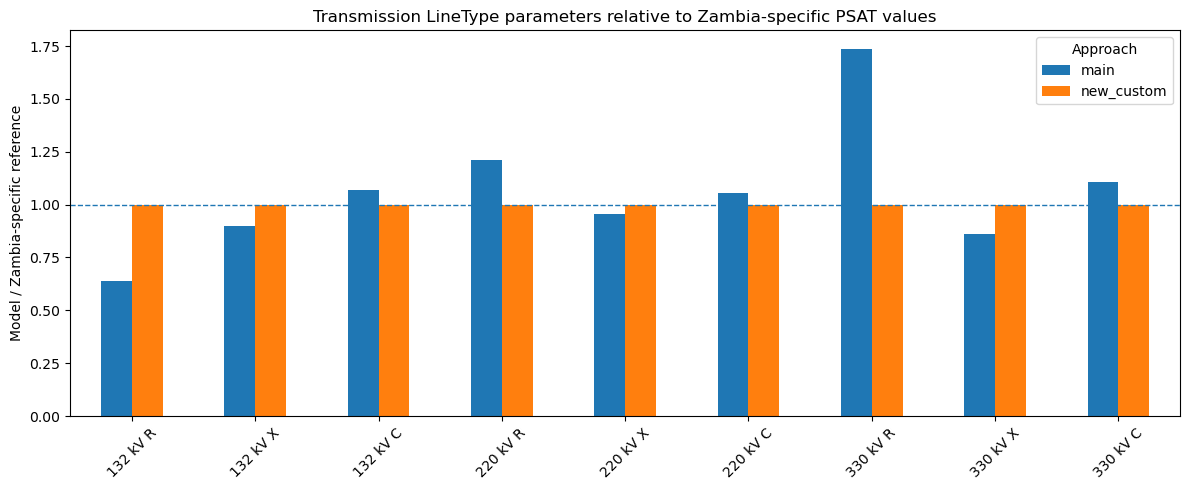

In [13]:
ratio_df = psat_comparison.copy()
ratio_df["model_to_reference_ratio"] = (
    ratio_df["model_value"] / ratio_df["reference_value"]
)

parameter_labels = {
    "r_per_length": "R",
    "x_per_length": "X",
    "c_per_length": "C",
}

ratio_df["case"] = ratio_df.apply(
    lambda row: (
        f"{int(row['v_nom'])} kV "
        f"{parameter_labels[row['parameter']]}"
    ),
    axis=1,
)

case_order = [
    f"{voltage} kV {parameter}"
    for voltage in [132, 220, 330]
    for parameter in ["R", "X", "C"]
]

plot_df = (
    ratio_df.pivot(
        index="case",
        columns="approach",
        values="model_to_reference_ratio",
    )
    .reindex(case_order)
)

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 5),
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("")
ax.set_ylabel("Model / Zambia-specific reference")
ax.set_title(
    "Transmission LineType parameters relative to "
    "Zambia-specific PSAT values"
)
ax.legend(title="Approach")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 8. Capacity impact

Changes in nominal transmission capacity are a **consequence** of the revised
LineType parameterization; they are not themselves evidence that the new
representation is more accurate.

The topology, line lengths and number of parallel circuits are unchanged between
the two approaches. The capacity differences below therefore isolate the effect
of changing the representative conductor ampacity assigned to each voltage
level.

The 66 and 88 kV capacities remain unchanged. Capacity decreases at 120/132 and
220 kV, while the 330 kV capacity doubles because `ZM_330kV` represents the
documented twin-Bison conductor configuration rather than the legacy
single-Bison representation.


,lines,circuits,main_mean_s_nom,new_custom_mean_s_nom,mean_change_pct
v_nom,,,,,
66.0,96,101.0,56.526561,56.526561,0.000000
88.0,22,24.0,78.150132,78.150132,0.000000
120.0,1,1.0,116.393814,97.687666,-16.071429
132.0,30,30.0,128.033196,107.456432,-16.071429
220.0,14,16.0,374.518872,348.389648,-6.976744
330.0,42,47.0,511.697296,1023.394591,100.000000


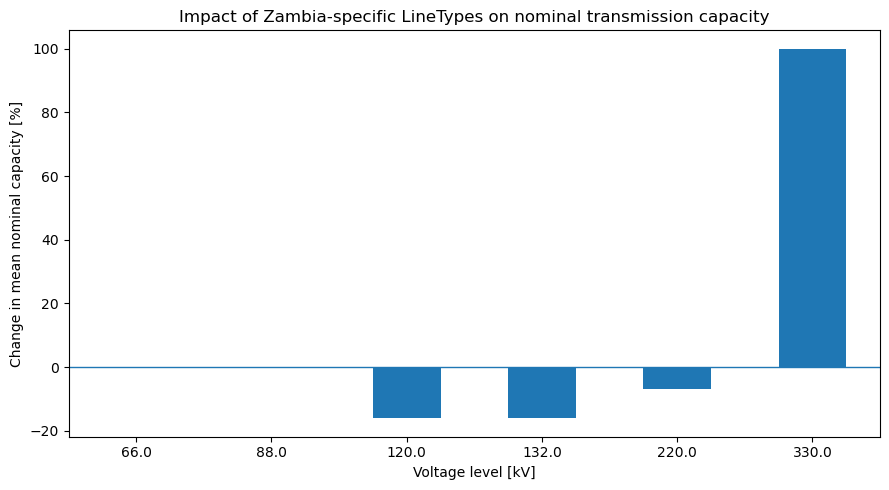

In [14]:
capacity_main = (
    line_properties["main"]["base"]
    .groupby("v_nom")
    .agg(
        lines=("s_nom", "size"),
        circuits=("num_parallel", "sum"),
        main_mean_s_nom=("s_nom", "mean"),
    )
)

capacity_new_custom = (
    line_properties["new_custom"]["base"]
    .groupby("v_nom")
    .agg(
        new_custom_mean_s_nom=("s_nom", "mean"),
    )
)

capacity_comparison = capacity_main.join(capacity_new_custom)

capacity_comparison["mean_change_pct"] = (
    capacity_comparison["new_custom_mean_s_nom"]
    / capacity_comparison["main_mean_s_nom"]
    - 1
) * 100

display(capacity_comparison)

ax = capacity_comparison["mean_change_pct"].plot(
    kind="bar",
    figsize=(9, 5),
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_xlabel("Voltage level [kV]")
ax.set_ylabel("Change in mean nominal capacity [%]")
ax.set_title(
    "Impact of Zambia-specific LineTypes on "
    "nominal transmission capacity"
)
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 9. Propagation through the workflow

A representative LineType assignment is only useful if it survives the workflow correctly.
The following cells compare `base`, `elec`, and `elec_s` for both approaches.

Note that simplification can legitimately change voltage levels, circuit aggregation and branch
parameters. This section therefore checks consistency of the transformation rather than requiring
the simplified network to be identical to the base network.


In [15]:
workflow_summary = []

for approach, stages in line_properties.items():
    for stage, df in stages.items():
        workflow_summary.append(
            {
                "approach": approach,
                "stage": stage,
                "lines": len(df),
                "voltage_levels_kV": sorted(df["v_nom"].dropna().unique().tolist()),
                "line_types": sorted(df["type"].dropna().astype(str).unique().tolist()),
                "total_circuits": df["num_parallel"].sum(),
                "total_s_nom_MVA": df["s_nom"].sum(),
            }
        )

workflow_summary = pd.DataFrame(workflow_summary)
workflow_summary


,approach,stage,lines,voltage_levels_kV,line_types,total_circuits,total_s_nom_MVA
0,main,base,205,"[66.0, 88.0, 120.0, 132.0, 220.0, 330.0]","[ACSR Bison 330.0, ACSR Panther 132.0, ACSR Wo...",219.000000,37837.793045
1,main,elec,205,"[66.0, 88.0, 120.0, 132.0, 220.0, 330.0]","[ACSR Bison 330.0, ACSR Panther 132.0, ACSR Wo...",219.000000,37837.793045
2,main,elec_s,107,[330.0],[ACSR Bison 330.0],60.166667,27511.895027
3,new_custom,base,205,"[66.0, 88.0, 120.0, 132.0, 220.0, 330.0]","[ZM_132kV, ZM_220kV, ZM_330kV, ZM_66kV, ZM_88kV]",219.000000,58327.261278
4,new_custom,elec,205,"[66.0, 88.0, 120.0, 132.0, 220.0, 330.0]","[ZM_132kV, ZM_220kV, ZM_330kV, ZM_66kV, ZM_88kV]",219.000000,58327.261278
5,new_custom,elec_s,107,[330.0],[ZM_330kV],51.503333,47100.973969


In [16]:
main_s = networks["main"]["elec_s"].lines
new_s = networks["new_custom"]["elec_s"].lines

common_s = main_s.index.intersection(new_s.index)

simplified_topology_check = pd.Series(
    {
        "main_lines": len(main_s),
        "new_custom_lines": len(new_s),
        "common_lines": len(common_s),
        "same_index": main_s.index.equals(new_s.index),
        "same_bus0": main_s.loc[common_s, "bus0"].equals(
            new_s.loc[common_s, "bus0"]
        ),
        "same_bus1": main_s.loc[common_s, "bus1"].equals(
            new_s.loc[common_s, "bus1"]
        ),
        "same_v_nom": main_s.loc[common_s, "v_nom"].equals(
            new_s.loc[common_s, "v_nom"]
        ),
        "same_length": np.allclose(
            main_s.loc[common_s, "length"],
            new_s.loc[common_s, "length"],
            equal_nan=True,
        ),
    },
    name="simplified_topology_check",
)

display(simplified_topology_check)

simplified_parameter_summary = pd.DataFrame(
    {
        "main": {
            "total_num_parallel": main_s["num_parallel"].sum(),
            "total_s_nom_MVA": main_s["s_nom"].sum(),
        },
        "new_custom": {
            "total_num_parallel": new_s["num_parallel"].sum(),
            "total_s_nom_MVA": new_s["s_nom"].sum(),
        },
    }
)

display(simplified_parameter_summary)


main_lines           107
new_custom_lines     107
common_lines         107
same_index          True
same_bus0           True
same_bus1           True
same_v_nom          True
same_length         True
Name: simplified_topology_check, dtype: object

,main,new_custom
total_num_parallel,60.166667,51.503333
total_s_nom_MVA,27511.895027,47100.973969


### Interpretation of the simplified network

The simplified networks preserve the same topology: both approaches contain
107 lines with identical line indices, endpoints, nominal voltage and length.

The different `num_parallel` values after simplification should **not** be
interpreted as a change in the physical number of circuits. During voltage
simplification, PyPSA-Zambia maps lines to the common voltage layer, assigns
the corresponding LineType, preserves `s_nom`, and recalculates

$$n_{parallel}=\frac{S_{nom}}{\sqrt{3} V_{nom} I_{nom}}.
$$

`num_parallel` is therefore an equivalent quantity after simplification.
Because `ZM_330kV` uses `i_nom = 1.6 kA`, compared with `0.8 kA` for the
legacy `ACSR Bison 330.0` type, fewer equivalent parallel circuits are needed
for a given transmission capacity.

The different total `s_nom` values do not originate from a topology change.
They reflect the different nominal capacities already introduced by the
LineType parameterization before simplification, together with the subsequent
network simplification steps.


## 10. Evidence and limitations summary

The strength and nature of the available Zambia-specific evidence differ by
voltage level.

| Voltage | `main` representation | `new_custom` representation | Zambia-specific evidence | Interpretation |
| ---: | --- | --- | --- | --- |
| 66 kV | `ACSR Wolf 66.0` | `ZM_66kV` | JICA/ZESCO inventory: Wolf is dominant, with Dog and Tiger also documented | Electrical parameters are unchanged. The improvement is mainly an explicit Zambia-specific mapping; this remains a representative approximation. |
| 88 kV | `ACSR Wolf 66.0` | `ZM_88kV` | JICA/ZESCO inventory: mixed Dog/Wolf population | Electrical parameters are unchanged and still Wolf-based. This is the most uncertain representative LineType and should not be interpreted as a fully validated 88 kV parameterization. |
| 120 kV | `ACSR Panther 132.0` | `ZM_132kV` | No separate 120 kV representative LineType is defined | Only one model line is affected. It is represented by the nearest available 132 kV LineType and is therefore an explicit approximation. |
| 132 kV | `ACSR Panther 132.0` | `ZM_132kV` | Wolf conductor evidence plus published ZESCO PSAT electrical parameters | The new type replaces the legacy Panther parameterization with a Zambia-specific conductor basis and published electrical parameters. |
| 220 kV | `ACSR Zebra 220.0` | `ZM_220kV` | Bison conductor evidence plus published ZESCO PSAT electrical parameters | The new type replaces the legacy Zebra parameterization with Zambia-specific evidence. |
| 330 kV | `ACSR Bison 330.0`, `i_nom = 0.8 kA` | `ZM_330kV`, `i_nom = 1.6 kA` | Twin-bundled Bison documented by JICA/ZESCO and ZTIP; published ZESCO PSAT electrical parameters | This is the clearest structural change: both the electrical parameters and the documented twin-Bison conductor configuration are represented explicitly. |

The validation therefore supports different levels of confidence across the
network. The evidence is strongest for 132, 220 and 330 kV. At 66 kV the
representative conductor choice is reasonably supported but the electrical
parameters are unchanged from the previous model. At 88 kV both the mixed
conductor population and the lack of an independent Zambia-specific electrical
parameter reference remain important limitations.
